In [ ]:
#| hide
from fastcore.utils import *
from fastspec.oapi import *
from fastspec.spec import *
from cachy.core import enable_cachy
import os, json, yaml
from pathlib import Path
from IPython.display import Markdown

In [ ]:
#| hide
enable_cachy(hdrs=('content-type',))

# fastspec

> Dynamic OpenAPI and discovery spec client for Python — turn any API spec into a fully-typed async client with attribute chaining, streaming, and file uploads

## Install

```sh
pip install fastspec
```

## Quick Start

fastspec turns any OpenAPI (or Google Discovery) spec into a fully async Python client. Load a spec, create a client, and call any endpoint with attribute chaining.

### Loading Specs

fastspec supports both OpenAPI (JSON/YAML) and Google Discovery specs:

In [ ]:
import yaml

specs_path = Path('../specs/')

# OpenAPI specs (Anthropic, OpenAI, GitHub, Stripe)
ant_spec  = SpecParser.from_openapi(dict2obj(yaml.safe_load((specs_path/'anthropic.yml').read_text())))
oai_spec  = SpecParser.from_openapi(dict2obj(yaml.safe_load((specs_path/'openai.with-code-samples.yml').read_text())))
gh_spec   = SpecParser.from_openapi(dict2obj(json.loads((specs_path/'github.json').read_text())))

# Google Discovery spec (Gemini)
gem_spec  = SpecParser.from_discovery(dict2obj(json.loads((specs_path/'gemini.json').read_text())))

ant_spec, oai_spec, gh_spec, gem_spec

(SpecParser(base_url='https://api.anthropic.com', ops=47),
 SpecParser(base_url='https://api.openai.com/v1', ops=241),
 SpecParser(base_url='https://api.github.com', ops=1112),
 SpecParser(base_url='https://generativelanguage.googleapis.com/', ops=79))

### Creating Clients

Pass a parsed spec and any required auth headers to `OpenAPIClient`:

In [ ]:
ant_cli = OpenAPIClient(ant_spec, headers={"x-api-key": os.environ["ANTHROPIC_API_KEY"], "anthropic-version": "2023-06-01"})
oai_cli = OpenAPIClient(oai_spec, headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"})
gh_cli  = OpenAPIClient(gh_spec,  headers={"Authorization": f"token {os.environ['GITHUB_TOKEN']}"})

### Exploring Operations

Every client organizes endpoints into groups. Use `doc()` to browse what's available:

In [ ]:
ant_cli.messages

- [messages.messages_post](https://docs.claude.com/en/docs/initial-setup)(model, messages, max_tokens, cache_control, container, inference_geo, metadata, output_config, service_tier, stop_sequences, stream, system, temperature, thinking, tool_choice, tools, top_k, top_p): *Create a Message*
- [messages.message_batches_post](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(requests): *Create a Message Batch*
- [messages.message_batches_list](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(before_id, after_id, limit): *List Message Batches*
- [messages.message_batches_retrieve](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve a Message Batch*
- [messages.message_batches_delete](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Delete a Message Batch*
- [messages.message_batches_cancel](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Cancel a Message Batch*
- [messages.message_batches_results](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve Message Batch results*
- [messages.messages_count_tokens_post](https://docs.claude.com/en/docs/build-with-claude/token-counting)(messages, model, cache_control, output_config, system, thinking, tool_choice, tools): *Count tokens in a Message*
- [messages.beta_message_batches_post](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(requests): *Create a Message Batch*
- [messages.beta_message_batches_list](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(before_id, after_id, limit): *List Message Batches*
- [messages.beta_message_batches_retrieve](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve a Message Batch*
- [messages.beta_message_batches_delete](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Delete a Message Batch*
- [messages.beta_message_batches_cancel](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Cancel a Message Batch*
- [messages.beta_message_batches_results](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve Message Batch results*
- [messages.beta_messages_count_tokens_post](https://docs.claude.com/en/docs/build-with-claude/token-counting)(messages, model, cache_control, context_management, mcp_servers, output_config, output_format, speed, system, thinking, tool_choice, tools): *Count tokens in a Message*

Drill into any operation to see its full signature and parameter docs:

In [ ]:
ant_cli.messages.messages_post

Create a Message

Docs: https://docs.claude.com/en/docs/initial-setup

Parameters:
- model (str, required): The model that will complete your prompt.\n\nSee [models](https://docs.anthropic.com/en/docs/models-overview) for additional details and options.
- messages (list, required): Input messages. Our models are trained to operate on alternating `user` and `assistant` conversational turns. When creating a new `Message`, you specify the prior conversational turns with the `messages` parameter, and the model then generates the next `Message` in the conversation. Consecutive `user` or `assistant` turns in your request will be combined into a single turn. Each input message must be an object with a `role` and `content`. You can specify a single `user`-role message, or you can include multiple `user` and `assistant` messages. If the final message uses the `assistant` role, the response content will continue immediately from the content in that message. This can be used to constrain part of the model's response. Example with a single `user` message: ```json [{"role": "user", "content": "Hello, Claude"}] ``` Example with multiple conversational turns: ```json [ {"role": "user", "content": "Hello there."}, {"role": "assistant", "content": "Hi, I'm Claude. How can I help you?"}, {"role": "user", "content": "Can you explain LLMs in plain English?"}, ] ``` Example with a partially-filled response from Claude: ```json [ {"role": "user", "content": "What's the Greek name for Sun? (A) Sol (B) Helios (C) Sun"}, {"role": "assistant", "content": "The best answer is ("}, ] ``` Each input message `content` may be either a single `string` or an array of content blocks, where each block has a specific `type`. Using a `string` for `content` is shorthand for an array of one content block of type `"text"`. The following input messages are equivalent: ```json {"role": "user", "content": "Hello, Claude"} ``` ```json {"role": "user", "content": [{"type": "text", "text": "Hello, Claude"}]} ``` See [input examples](https://docs.claude.com/en/api/messages-examples). Note that if you want to include a [system prompt](https://docs.claude.com/en/docs/system-prompts), you can use the top-level `system` parameter — there is no `"system"` role for input messages in the Messages API. There is a limit of 100,000 messages in a single request.
- max_tokens (int, required): The maximum number of tokens to generate before stopping. Note that our models may stop _before_ reaching this maximum. This parameter only specifies the absolute maximum number of tokens to generate. Different models have different maximum values for this parameter. See [models](https://docs.claude.com/en/docs/models-overview) for details.
- cache_control (dict, optional): Top-level cache control automatically applies a cache_control marker to the last cacheable block in the request.
- container (str, optional): Container identifier for reuse across requests.
- inference_geo (str, optional): Specifies the geographic region for inference processing. If not specified, the workspace's `default_inference_geo` is used.
- metadata (dict, optional): An object describing metadata about the request.
- output_config (dict, optional): Configuration options for the model's output, such as the output format.
- service_tier (str, optional): Determines whether to use priority capacity (if available) or standard capacity for this request. Anthropic offers different levels of service for your API requests. See [service-tiers](https://docs.claude.com/en/api/service-tiers) for details.
- stop_sequences (list, optional): Custom text sequences that will cause the model to stop generating. Our models will normally stop when they have naturally completed their turn, which will result in a response `stop_reason` of `"end_turn"`. If you want the model to stop generating when it encounters custom strings of text, you can use the `stop_sequences` parameter. If the model encounters one of the custom sequences, the response `stop_reason` value will be `"stop_sequence"` and the response `stop_sequence` value will contain the matched stop sequence.
- stream (bool, optional): Whether to incrementally stream the response using server-sent events. See [streaming](https://docs.claude.com/en/api/messages-streaming) for details.
- system (, optional): System prompt. A system prompt is a way of providing context and instructions to Claude, such as specifying a particular goal or role. See our [guide to system prompts](https://docs.claude.com/en/docs/system-prompts).
- temperature (float, optional): Amount of randomness injected into the response. Defaults to `1.0`. Ranges from `0.0` to `1.0`. Use `temperature` closer to `0.0` for analytical / multiple choice, and closer to `1.0` for creative and generative tasks. Note that even with `temperature` of `0.0`, the results will not be fully deterministic.
- thinking (dict, optional): Configuration for enabling Claude's extended thinking. When enabled, responses include `thinking` content blocks showing Claude's thinking process before the final answer. Requires a minimum budget of 1,024 tokens and counts towards your `max_tokens` limit. See [extended thinking](https://docs.claude.com/en/docs/build-with-claude/extended-thinking) for details.
- tool_choice (dict, optional): How the model should use the provided tools. The model can use a specific tool, any available tool, decide by itself, or not use tools at all.
- tools (list, optional): Definitions of tools that the model may use. If you include `tools` in your API request, the model may return `tool_use` content blocks that represent the model's use of those tools. You can then run those tools using the tool input generated by the model and then optionally return results back to the model using `tool_result` content blocks. There are two types of tools: **client tools** and **server tools**. The behavior described below applies to client tools. For [server tools](https://docs.claude.com/en/docs/agents-and-tools/tool-use/overview\#server-tools), see their individual documentation as each has its own behavior (e.g., the [web search tool](https://docs.claude.com/en/docs/agents-and-tools/tool-use/web-search-tool)). Each tool definition includes: * `name`: Name of the tool. * `description`: Optional, but strongly-recommended description of the tool. * `input_schema`: [JSON schema](https://json-schema.org/draft/2020-12) for the tool `input` shape that the model will produce in `tool_use` output content blocks. For example, if you defined `tools` as: ```json [ { "name": "get_stock_price", "description": "Get the current stock price for a given ticker symbol.", "input_schema": { "type": "object", "properties": { "ticker": { "type": "string", "description": "The stock ticker symbol, e.g. AAPL for Apple Inc." } }, "required": ["ticker"] } } ] ``` And then asked the model "What's the S&P 500 at today?", the model might produce `tool_use` content blocks in the response like this: ```json [ { "type": "tool_use", "id": "toolu_01D7FLrfh4GYq7yT1ULFeyMV", "name": "get_stock_price", "input": { "ticker": "^GSPC" } } ] ``` You might then run your `get_stock_price` tool with `{"ticker": "^GSPC"}` as an input, and return the following back to the model in a subsequent `user` message: ```json [ { "type": "tool_result", "tool_use_id": "toolu_01D7FLrfh4GYq7yT1ULFeyMV", "content": "259.75 USD" } ] ``` Tools can be used for workflows that include running client-side tools and functions, or more generally whenever you want the model to produce a particular JSON structure of output. See our [guide](https://docs.claude.com/en/docs/tool-use) for more details.
- top_k (int, optional): Only sample from the top K options for each subsequent token. Used to remove "long tail" low probability responses. [Learn more technical details here](https://towardsdatascience.com/how-to-sample-from-language-models-682bceb97277). Recommended for advanced use cases only. You usually only need to use `temperature`.
- top_p (float, optional): Use nucleus sampling. In nucleus sampling, we compute the cumulative distribution over all the options for each subsequent token in decreasing probability order and cut it off once it reaches a particular probability specified by `top_p`. You should either alter `temperature` or `top_p`, but not both. Recommended for advanced use cases only. You usually only need to use `temperature`.

## Anthropic

A simple message request:

In [ ]:
resp = await ant_cli.messages.messages_post(
    model="claude-sonnet-4-20250514",
    messages=[{"role": "user", "content": "What is FastSpec?"}],
    max_tokens=64,)
resp['content'][0]['text']

TypeError: byte indices must be integers or slices, not str

In [ ]:
resp

b'{"model":"claude-sonnet-4-20250514","id":"msg_015aRghzSaoMQDphxCFf2Nhs","type":"message","role":"assistant","content":[{"type":"text","text":"FastSpec could refer to a few different things depending on the context. Here are the most likely meanings:\\n\\n## 1. **FastSpec Testing Framework**\\nFastSpec is a testing framework, particularly known in the Scala ecosystem, that provides:\\n- Fast, parallel test execution\\n- Readable test syntax"}],"stop_reason":"max_tokens","stop_sequence":null,"stop_details":null,"usage":{"input_tokens":12,"cache_creation_input_tokens":0,"cache_read_input_tokens":0,"cache_creation":{"ephemeral_5m_input_tokens":0,"ephemeral_1h_input_tokens":0},"output_tokens":64,"service_tier":"standard","inference_geo":"not_available"}}'

With streaming — just pass `stream=True` and iterate:

In [ ]:
resp = await ant_cli.messages.messages_post(
    model="claude-sonnet-4-20250514",
    messages=[{"role": "user", "content": "Say hello in 3 languages."}],
    max_tokens=128, stream=True)
async for ev in resp: print(ev['type'], end=' ')

message_start content_block_start ping content_block_delta content_block_delta content_block_stop message_delta 

## OpenAI

### Chat Completion

In [ ]:
resp = await oai_cli.chat.create_chat_completion(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "What is fastspec?"}],
    max_tokens=64)
resp['choices'][0]['message']['content']

'As of my last knowledge update in October 2023, "FastSpec" does not refer to a widely recognized term, concept, or product in technology, science, or other fields. It\'s possible that it could refer to specific software, a tool, or a methodology that has emerged after that date or is not well'

### Text-to-Speech (file output)

In [ ]:
resp = await oai_cli.audio.create_speech(model="tts-1", input="Hello from fastspec!", voice="alloy")
Path("hello.mp3").write_bytes(resp)
print(f"Saved {len(resp)} bytes to hello.mp3")

Saved 24480 bytes to hello.mp3


### Transcription (file upload + streaming)

In [ ]:
resp = await oai_cli.audio.create_transcription(
    file=open("hello.mp3", "rb"), model="gpt-4o-transcribe", stream=True)
async for ev in resp: print(ev.get('delta', ''), end='')

Hello from FastSpec.

## Gemini

Google Discovery specs use nested resource groups with attribute chaining:

In [ ]:
gem_cli = OpenAPIClient(gem_spec, headers={"x-goog-api-key": os.environ["GEMINI_API_KEY"]})
gem_cli.models

- models.generate_content(model, contents, system_instruction, tools, tool_config, safety_settings, generation_config, cached_content, service_tier, store): *Generates a model response given an input `GenerateContentRequest`. Refer to the [text generation guide](https://ai.google.dev/gemini-api/docs/text-generation) for detailed usage information. Input capabilities differ between models, including tuned models. Refer to the [model guide](https://ai.google.dev/gemini-api/docs/models/gemini) and [tuning guide](https://ai.google.dev/gemini-api/docs/model-tuning) for details.*
- models.generate_answer(model, contents, answer_style, inline_passages, semantic_retriever, safety_settings, temperature): *Generates a grounded answer from the model given an input `GenerateAnswerRequest`.*
- models.stream_generate_content(model, contents, system_instruction, tools, tool_config, safety_settings, generation_config, cached_content, service_tier, store): *Generates a [streamed response](https://ai.google.dev/gemini-api/docs/text-generation?lang=python#generate-a-text-stream) from the model given an input `GenerateContentRequest`.*
- models.embed_content(model, content, task_type, title, output_dimensionality): *Generates a text embedding vector from the input `Content` using the specified [Gemini Embedding model](https://ai.google.dev/gemini-api/docs/models/gemini#text-embedding).*
- models.batch_embed_contents(model, requests): *Generates multiple embedding vectors from the input `Content` which consists of a batch of strings represented as `EmbedContentRequest` objects.*
- models.count_tokens(model, contents, generate_content_request): *Runs a model's tokenizer on input `Content` and returns the token count. Refer to the [tokens guide](https://ai.google.dev/gemini-api/docs/tokens) to learn more about tokens.*
- models.batch_generate_content(model, batch): *Enqueues a batch of `GenerateContent` requests for batch processing.*
- models.async_batch_embed_content(model, batch): *Enqueues a batch of `EmbedContent` requests for batch processing. We have a `BatchEmbedContents` handler in `GenerativeService`, but it was synchronized. So we name this one to be `Async` to avoid confusion.*
- models.generate_message(model, prompt, temperature, candidate_count, top_p, top_k): *Generates a response from the model given an input `MessagePrompt`.*
- models.count_message_tokens(model, prompt): *Runs a model's tokenizer on a string and returns the token count.*
- models.get(name): *Gets information about a specific `Model` such as its version number, token limits, [parameters](https://ai.google.dev/gemini-api/docs/models/generative-models#model-parameters) and other metadata. Refer to the [Gemini models guide](https://ai.google.dev/gemini-api/docs/models/gemini) for detailed model information.*
- models.list(page_size, page_token): *Lists the [`Model`s](https://ai.google.dev/gemini-api/docs/models/gemini) available through the Gemini API.*
- models.predict(model, instances, parameters): *Performs a prediction request.*
- models.predict_long_running(model, instances, parameters): *Same as Predict but returns an LRO.*
- models.generate_text(model, prompt, temperature, candidate_count, max_output_tokens, top_p, top_k, safety_settings, stop_sequences): *Generates a response from the model given an input message.*
- models.embed_text(model, text): *Generates an embedding from the model given an input message.*
- models.batch_embed_text(model, texts, requests): *Generates multiple embeddings from the model given input text in a synchronous call.*
- models.count_text_tokens(model, prompt): *Runs a model's tokenizer on a text and returns the token count.*

In [ ]:
resp = await gem_cli.models.generate_content(
    model="models/gemini-2.5-flash",
    contents=[{"parts": [{"text": "What is fastspec?"}]}])
resp['candidates'][0]['content']['parts'][0]['text'][:200]

"**FastSpec** is a Ruby gem designed to significantly speed up your RSpec test suite, particularly in large Rails applications.\n\nHere's a breakdown of what it is and how it works:\n\n### The Problem Fast"

Nested resource groups are accessed with attribute chaining:

In [ ]:
gem_cli.tuned_models.permissions.create

Create a permission to a specific resource.

Parameters:
- parent (str, required): Required. The parent resource of the `Permission`. Formats: `tunedModels/{tuned_model}` `corpora/{corpus}`
- role (str, required): Required. The role granted by this permission.
- name (str, optional): Output only. Identifier. The permission name. A unique name will be generated on create. Examples: tunedModels/{tuned_model}/permissions/{permission} corpora/{corpus}/permissions/{permission} Output only.
- grantee_type (str, optional): Optional. Immutable. The type of the grantee.
- email_address (str, optional): Optional. Immutable. The email address of the user of group which this permission refers. Field is not set when permission's grantee type is EVERYONE.

## GitHub

Route parameters (like `{owner}` and `{repo}`) are passed as regular function arguments:

In [ ]:
resp = await gh_cli.repos.get(owner="AnswerDotAI", repo="fastcore")
resp['full_name'], resp['description'], resp['stargazers_count']

('AnswerDotAI/fastcore', 'Python supercharged for the fastai library', 1088)

In [ ]:
gh_cli.repos.get

Get a repository

Docs: https://docs.github.com/organizations/managing-peoples-access-to-your-organization-with-roles/managing-security-managers-in-your-organization

Parameters:
- owner (str, required): The account owner of the repository. The name is not case sensitive.
- repo (str, required): The name of the repository without the `.git` extension. The name is not case sensitive.

## AI Tool Integration (`pyrun`)

fastspec clients can be made available to AI assistants via [solveit](https://github.com/AnswerDotAI/solveit)'s `pyrun` sandbox using `allow()`. Three levels of access are supported:

**Single method access** — lock down to specific operations:

In [ ]:
from PIL import Image

In [ ]:
allow({oai_cli.images: ['create_image'], OpFunc: ['__call__']})

Check `create_image` and create an image of 2 kittens using pyrun, save it and add a message to display it with PIL

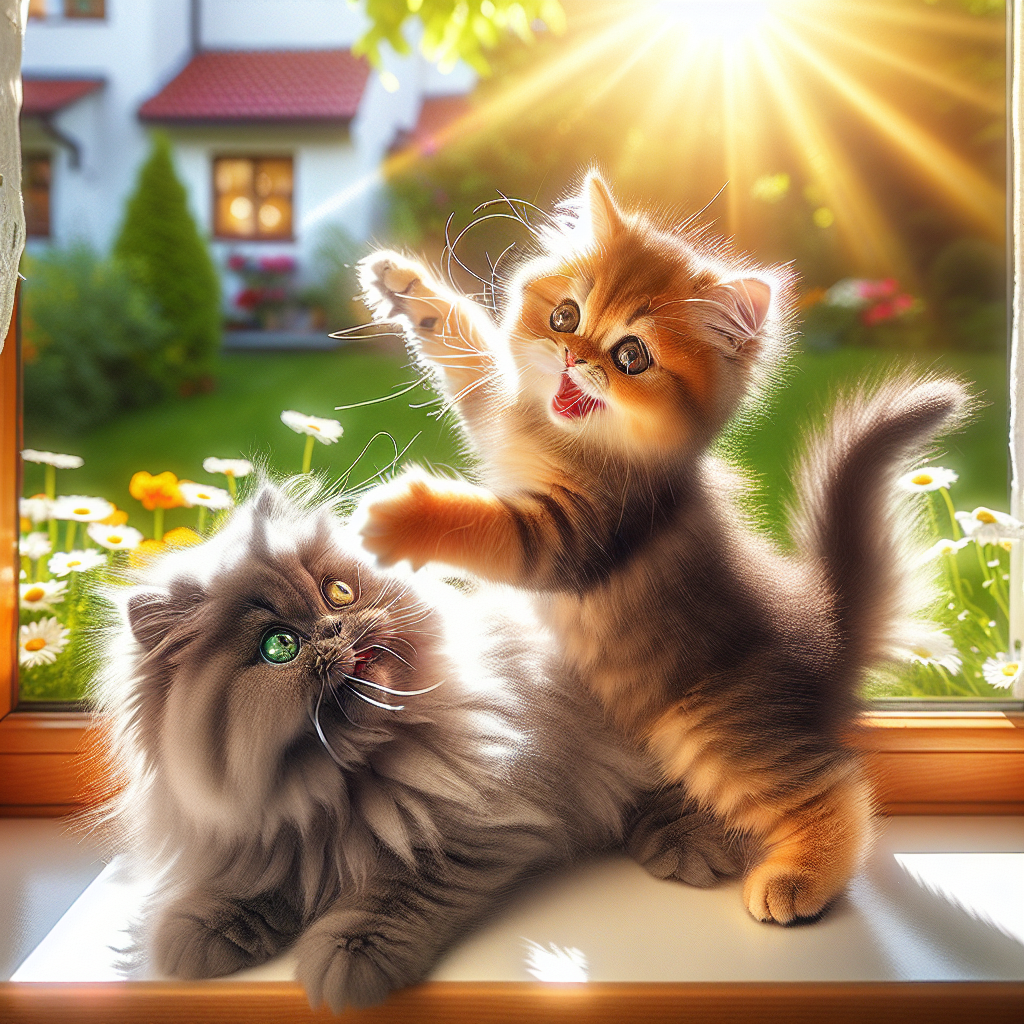

In [ ]:
Image.open("kittens.png")

**Single group access** — only specific groups:

In [ ]:
allow({oai_cli.chat: [...], OpFunc: ['__call__']})

Ok check what methods are in this group, and test using one of them

**Single client access** — all groups on one specific client:

In [ ]:
for nm, g in oai_cli.groups.items(): allow({g: [...], OpFunc: ['__call__']})

Ok let's see if you can access and use a group we've not tried yet

**Full API access** — all groups and methods on all clients:

In [ ]:
from safepyrun.core import allow
allow({OpGroup: [...], OpFunc: ['__call__']})